# Inicialización de Pesos y Redes Profundas: Construyendo MLPs Estables

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/04_deep_learning/02_inicializacion_y_redes_profundas.ipynb)

## Objetivos


- Comprender por qué apilar neuronas para formar Redes Neuronales Profundas (DNNs) genera inestabilidad matemática si no se controlan los pesos iniciales.
- Demostrar el problema de la simetría (inicialización en ceros) y el colapso de la varianza.
- Analizar y contrastar las estrategias de inicialización modernas (**Glorot/Xavier** vs. **He/Kaiming**) y su relación simbiótica con las funciones de activación.
- **Experimento Visual:** Rastrear la distribución de las activaciones a través de 10 capas ocultas para diagnosticar visualmente el flujo de información.



## Prerrequisitos


- Entendimiento del Perceptrón, el *Forward Pass* y el problema del *Vanishing Gradient*.
- Haber completado: [El Perceptrón y las Funciones de Activación](01_perceptron_y_activaciones.ipynb).

---



## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
setup_plot_style()

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow versión: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

TensorFlow versión: 2.20.0
GPU disponible: []


## 1. Introducción: El Desafío de la Profundidad


En el notebook anterior, descubrimos que la función **ReLU** solucionaba el problema del *Vanishing Gradient* que plagaba a la función Sigmoide. Parecía que ya podíamos apilar 100 capas y entrenar la red definitiva.

Sin embargo, si intentamos entrenar una red profunda asignando valores aleatorios a los pesos, la red no aprenderá nada. ¿Por qué?

El entrenamiento de una red neuronal es un proceso iterativo que comienza con una "suposición" inicial (los pesos iniciales). Si esa suposición es matemáticamente inestable, la señal de los datos de entrada se destruirá antes de llegar a la capa de salida.

### ⚠️ El Pecado Capital: Inicializar en Ceros


El error más común de un principiante es pensar: *"Si no sé qué valor poner, inicializaré todos los pesos en 0"*.

Si todos los pesos son cero, todas las neuronas de una capa calcularán exactamente el mismo valor ($0 \cdot x + b$). Durante el *Backpropagation*, todas recibirán exactamente el mismo gradiente y se actualizarán de la misma manera.
**Resultado:** La red neuronal de `1.000 `neuronas actuará como si tuviera **una sola neurona**. A esto se le llama el **Problema de la Simetría**. Los pesos deben ser aleatorios para "romper la simetría" y permitir que cada neurona aprenda una característica diferente.

### El Problema de la Varianza


Si usamos números aleatorios, ¿qué tan grandes deben ser?
- Si los pesos son **muy pequeños** (ej. varianza de `0.01`), la señal de entrada se multiplicará por fracciones una y otra vez. En la capa 10, la señal será `0.0000001`. La red se apaga.
- Si los pesos son **muy grandes** (ej. varianza de `2.0`), la señal se multiplicará exponencialmente. En la capa 10, la señal será infinita. La red explota (*Exploding Gradients*).

**El Criterio de Ingeniería:** Necesitamos que la varianza de las salidas de una capa sea exactamente igual a la varianza de sus entradas. La señal debe fluir sin amplificarse ni atenuarse.

## 2. La Evolución de la Inicialización


Para lograr que la varianza se mantenga estable ($Var(out) \approx Var(in)$), los investigadores desarrollaron fórmulas matemáticas específicas basadas en la cantidad de conexiones que entran a la neurona (`fan_in`) y las que salen (`fan_out`).

### Tabla de Decisión MLOps (Estándar 2026)



| Método | Distribución (Desviación Estándar) | Activación Recomendada | Justificación de Ingeniería |
| :--- | :--- | :--- | :--- |
| **Random Normal** | Fija (ej. 0.01) | Ninguna | Destruye la varianza en redes profundas. Solo para juguetes. |
| **Glorot / Xavier** | $\sqrt{\frac{2}{fan\_in + fan\_out}}$ | **Tanh, Sigmoide** | Asume que la función de activación es lineal en el centro. Falla con ReLU. |
| **He / Kaiming** | $\sqrt{\frac{2}{fan\_in}}$ | **ReLU, Leaky ReLU** | **El Estándar Actual.** Multiplica la varianza por 2 para compensar que ReLU "apaga" la mitad de las neuronas (los valores negativos). |
| **LeCun** | $\sqrt{\frac{1}{fan\_in}}$ | SELU | Usado en Redes Neuronales Auto-Normalizadas (SNNs). |


## 3. Experimento Visual: El Flujo de la Información


Vamos a demostrar esto empíricamente. Construimos una red de 10 capas ocultas (sin entrenarla). Pasamos un lote de datos aleatorios y observamos los **histogramas de las activaciones** en las capas 1, 5 y 10.

Si la inicialización es correcta, el histograma de la capa 10 debería verse muy similar al de la capa 1.

EXPERIMENTO 1: Inicialización Aleatoria Pequeña + Tanh


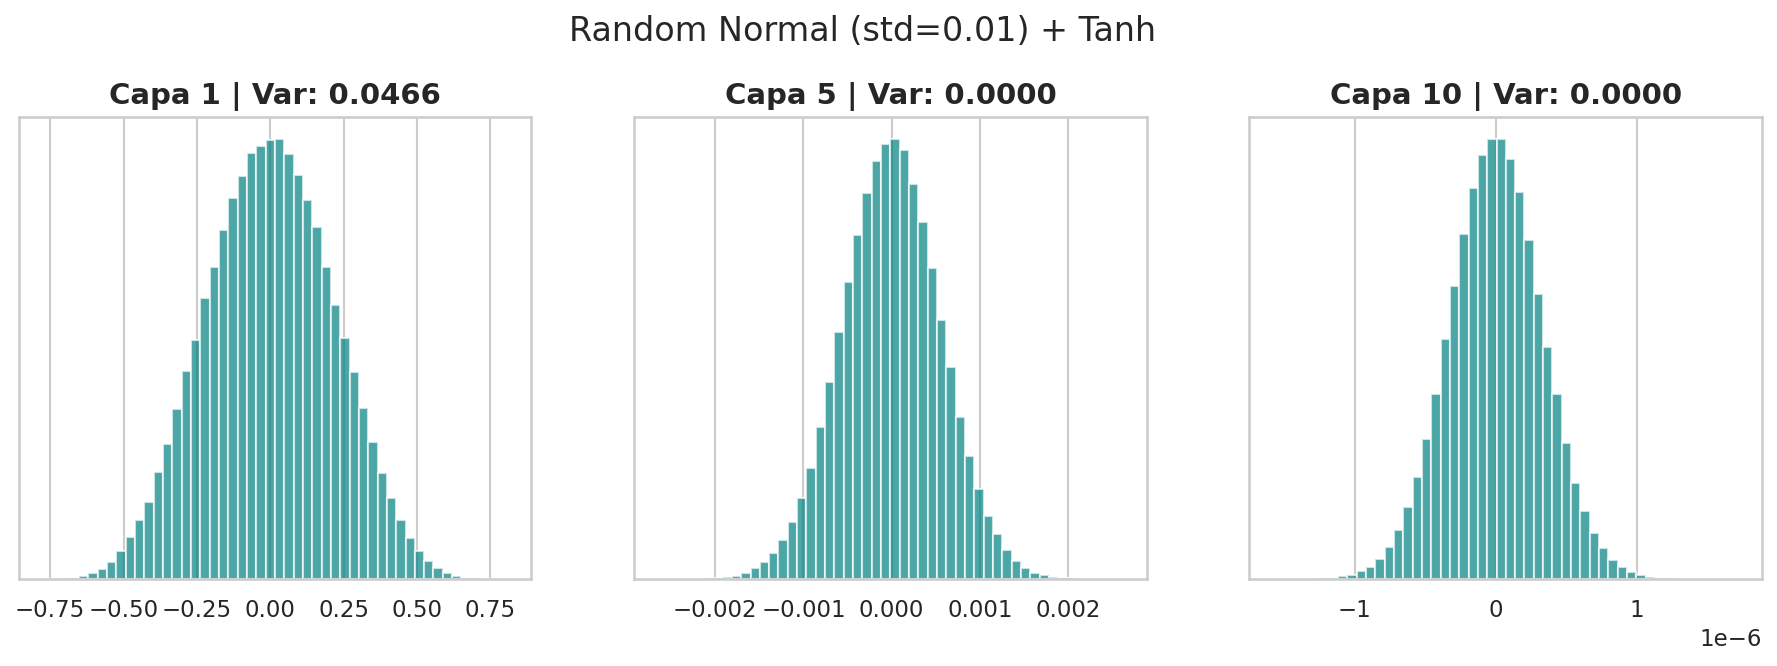

EXPERIMENTO 2: Inicialización Glorot (Xavier) + Tanh


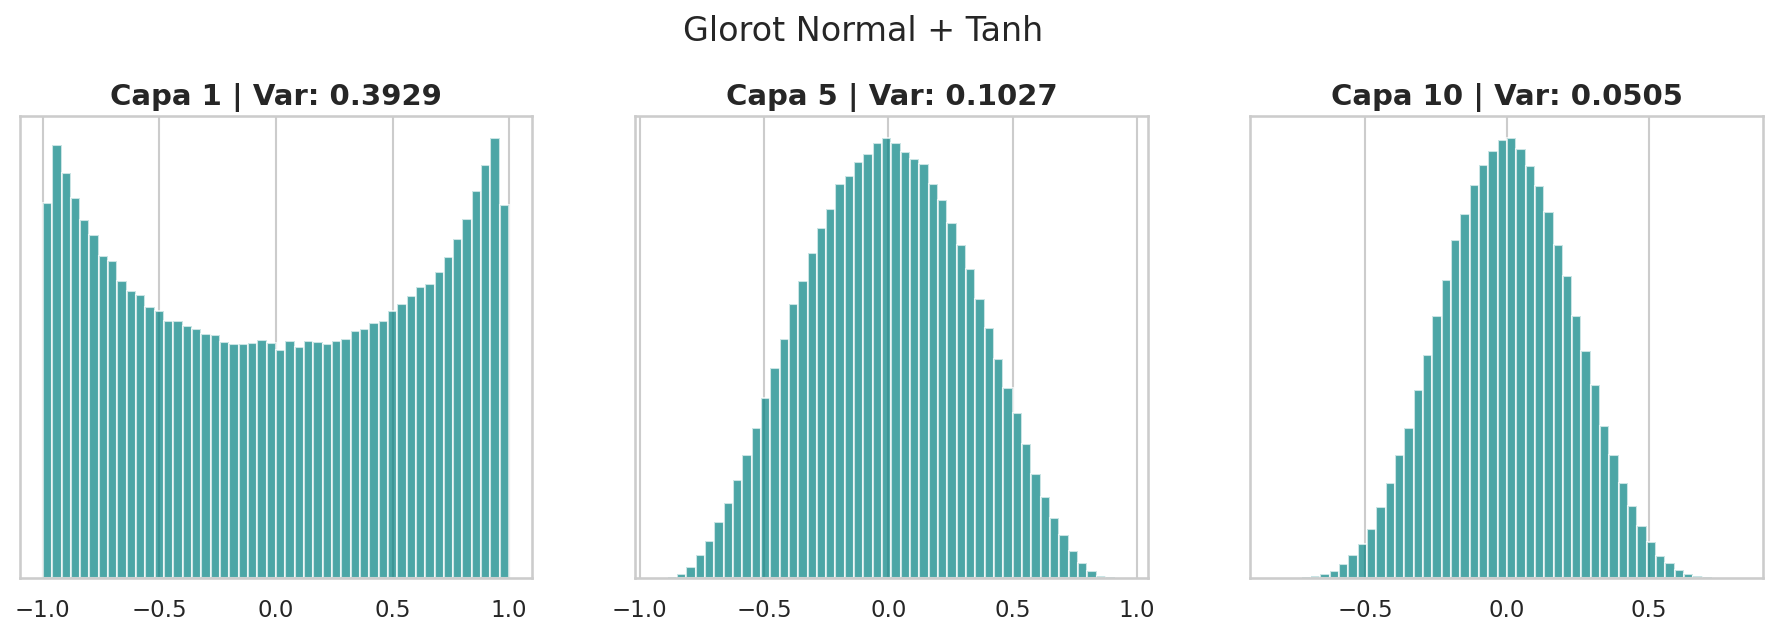

EXPERIMENTO 3: Inicialización Glorot (Xavier) + ReLU (El error común)


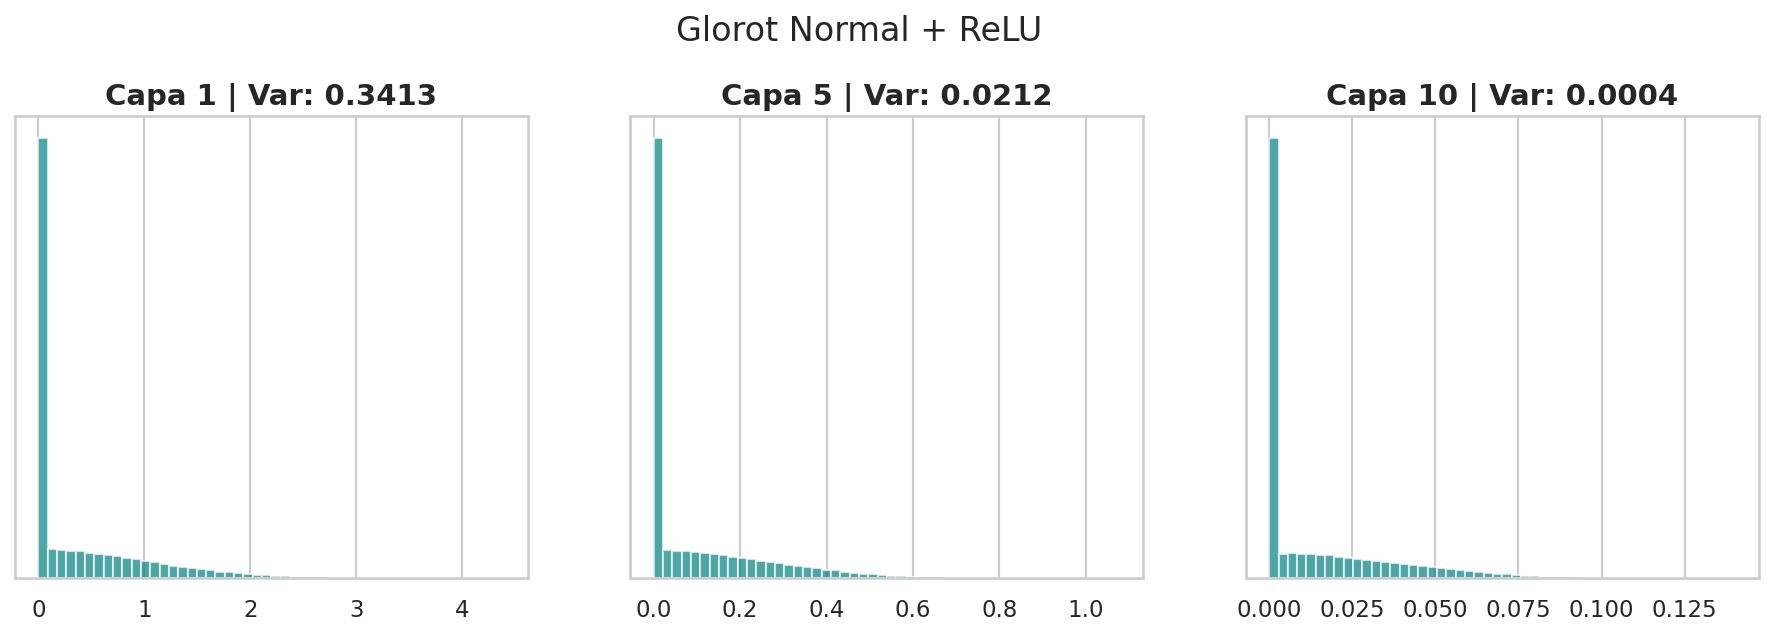

EXPERIMENTO 4: Inicialización He (Kaiming) + ReLU (El Estándar de la Industria)


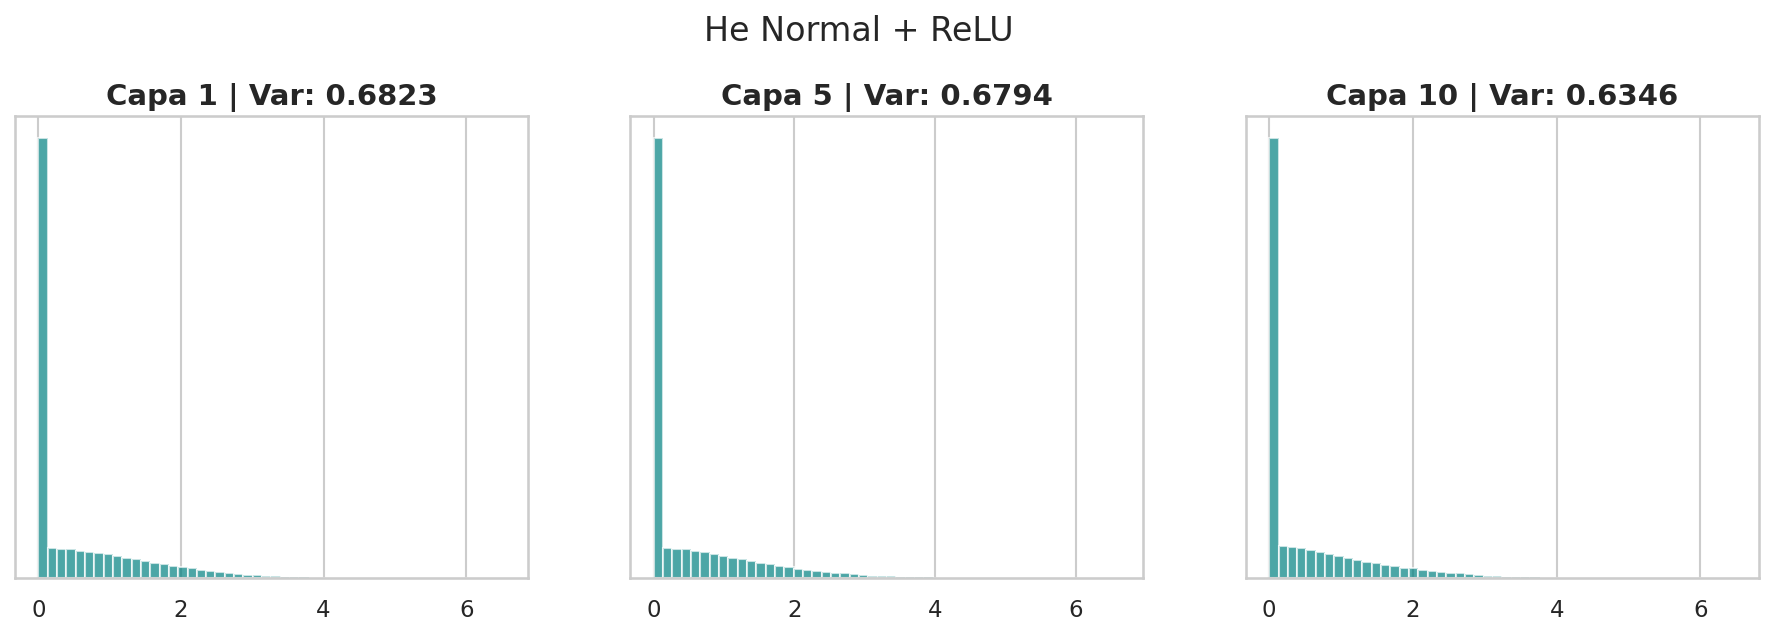

In [2]:
def simular_flujo_activaciones(inicializador, activacion, titulo):
    # 1. Creamos datos de entrada aleatorios (Media 0, Varianza 1)
    X = np.random.randn(1000, 512).astype(np.float32)

    # 2. Construimos una red de 10 capas
    activaciones_por_capa =[]
    entrada_actual = X

    for i in range(10):
        # Creamos una capa densa con 512 neuronas
        capa = tf.keras.layers.Dense(512, kernel_initializer=inicializador, activation=activacion)
        # Pasamos los datos (Forward Pass)
        salida = capa(entrada_actual)
        activaciones_por_capa.append(salida.numpy())
        entrada_actual = salida

    # 3. Visualizamos las capas 1, 5 y 10
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    capas_a_mostrar = [0, 4, 9] # Índices 0, 4 y 9 corresponden a las capas 1, 5 y 10

    for ax, idx in zip(axes, capas_a_mostrar):
        ax.hist(activaciones_por_capa[idx].flatten(), bins=50, color='teal', alpha=0.7)
        ax.set_title(f"Capa {idx + 1} | Var: {np.var(activaciones_por_capa[idx]):.4f}")
        ax.set_yticks([])

    fig.suptitle(titulo, fontsize=16, y=1.05)
    plt.show()

# Ejecutamos los experimentos
print("EXPERIMENTO 1: Inicialización Aleatoria Pequeña + Tanh")
simular_flujo_activaciones(tf.keras.initializers.RandomNormal(stddev=0.01), 'tanh', "Random Normal (std=0.01) + Tanh")

print("EXPERIMENTO 2: Inicialización Glorot (Xavier) + Tanh")
simular_flujo_activaciones(tf.keras.initializers.GlorotNormal(), 'tanh', "Glorot Normal + Tanh")

print("EXPERIMENTO 3: Inicialización Glorot (Xavier) + ReLU (El error común)")
simular_flujo_activaciones(tf.keras.initializers.GlorotNormal(), 'relu', "Glorot Normal + ReLU")

print("EXPERIMENTO 4: Inicialización He (Kaiming) + ReLU (El Estándar de la Industria)")
simular_flujo_activaciones(tf.keras.initializers.HeNormal(), 'relu', "He Normal + ReLU")

### Análisis: Leyendo los Histogramas


1. **Random Normal + Tanh:** En la Capa 1, la varianza ya cayó a `0.05`. Para la Capa 10, la varianza es **`0.0000`**. Todas las activaciones son cero. La red ha colapsado por completo.
2. **Glorot + Tanh:** La varianza inicia en `0.45` desde la Capa 1, sigue existiendo hasta la Capa 10 (`0.05`). La señal fluye.
3. **Glorot + ReLU (El Error):** Glorot fue diseñado asumiendo que la función de activación es simétrica. Pero ReLU convierte todos los números negativos en 0 (apaga la mitad de la red). Como resultado, la varianza se reduce a la mitad en cada capa. En la Capa 10, la varianza es **`0.0008`**. La red está muriendo.
4. **He + ReLU (El Estándar):** Kaiming He se dio cuenta del problema de ReLU y multiplicó la varianza inicial por 2. Observar el resultado: la varianza se mantiene estable alrededor de `0.70` incluso en la Capa 10. **Esta es la combinación que permite entrenar redes modernas.**

## 4. Impacto en el Entrenamiento Real



La teoría es fascinante, pero en ingeniería nos importan los resultados. Vamos a entrenar dos Perceptrones Multicapa (MLP) de 5 capas ocultas en el dataset **Fashion MNIST** (clasificación de ropa).

- **Modelo A (Anticuado):** Inicialización Aleatoria + Activación Sigmoide.
- **Modelo B (Moderno):** Inicialización He Normal + Activación ReLU.



> *5 minutos con CPU aprox...*

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Entrenando Modelo A (Sigmoide + Random Normal)...
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.4495 - loss: 1.2801 - val_accuracy: 0.6812 - val_loss: 0.7639
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.7753 - loss: 0.6249 - val_accuracy: 0.8228 - val_loss: 0.5308
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.8399 - loss: 0.4772 - val_accuracy: 0.8456 - val_loss: 0.4513
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.8561 - loss: 0.4234 - val_accuracy: 0.8504 - val_loss: 0.4342
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.8665 - loss: 0.3915 - val_accuracy: 0.8602 - val_loss: 0.4053
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.8746 - loss: 0.3663 - val_accura

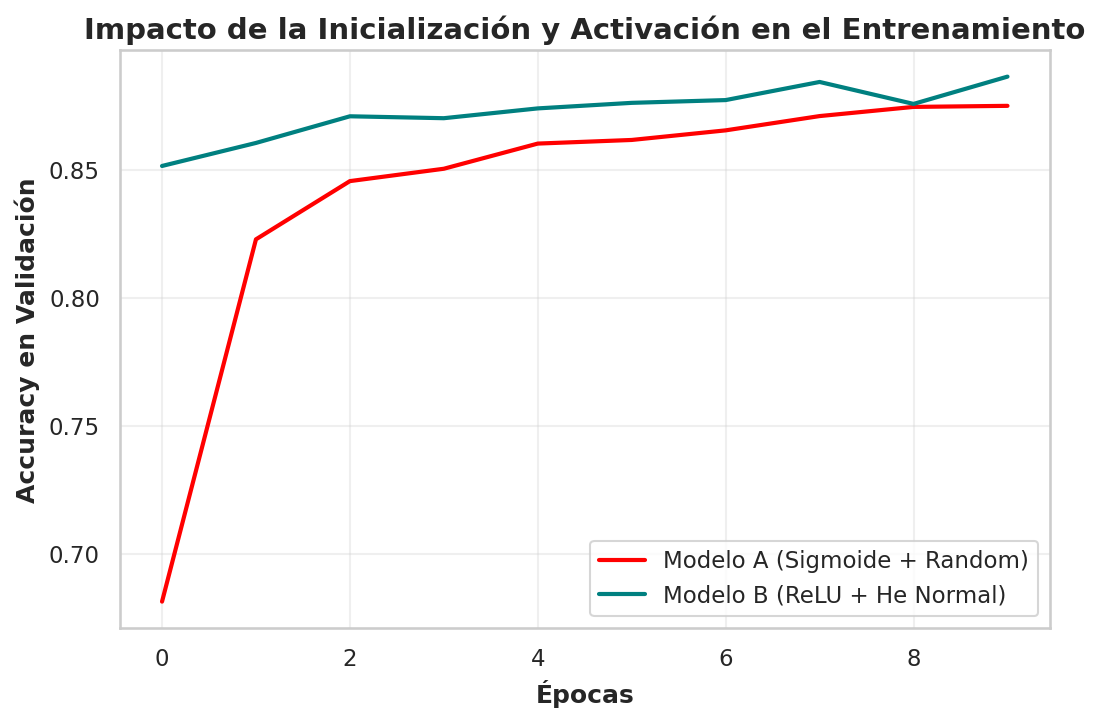

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras import Input
from tensorflow.keras.datasets import fashion_mnist

# 1. Carga y preprocesamiento de datos
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0 # Normalización de píxeles a [0, 1]

# 2. Función para construir el modelo
# Uso API Secuencial acá: básicamente una lista de Python para "apilar" capas
def construir_mlp(inicializador, activacion):
    modelo = Sequential([
        Input(shape=(28, 28)),
        Flatten(),
        Dense(256, activation=activacion, kernel_initializer=inicializador),
        Dense(256, activation=activacion, kernel_initializer=inicializador),
        Dense(256, activation=activacion, kernel_initializer=inicializador),
        Dense(256, activation=activacion, kernel_initializer=inicializador),
        Dense(256, activation=activacion, kernel_initializer=inicializador),
        Dense(10, activation='softmax') # Capa de salida para 10 clases
    ])
    modelo.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return modelo

# 3. Entrenamos ambos modelos
print("Entrenando Modelo A (Sigmoide + Random Normal)...")
modelo_a = construir_mlp(tf.keras.initializers.RandomNormal(stddev=0.01), 'sigmoid')
historia_a = modelo_a.fit(X_train, y_train, epochs=10, validation_split=0.2, verbose=1)

print("Entrenando Modelo B (ReLU + He Normal)...")
modelo_b = construir_mlp(tf.keras.initializers.HeNormal(), 'relu')
historia_b = modelo_b.fit(X_train, y_train, epochs=10, validation_split=0.2, verbose=1)

# 4. Visualizamos la convergencia
plt.figure(figsize=(8, 5))
plt.plot(historia_a.history['val_accuracy'], label='Modelo A (Sigmoide + Random)', color='red', linewidth=2)
plt.plot(historia_b.history['val_accuracy'], label='Modelo B (ReLU + He Normal)', color='teal', linewidth=2)

plt.title("Impacto de la Inicialización y Activación en el Entrenamiento", fontsize=14)
plt.xlabel("Épocas")
plt.ylabel("Accuracy en Validación")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

¿Qué pasó al final? ¿Bastante parecido salvo en las épocas iniciales?

Entra en juego el optimizador utilizado, Adam (Estimación Adaptativa de Momentos, del inglés).

Adam es un optimizador tan avanzado que a veces logra "rescatar" malas inicializaciones, adaptando el *learning rate*. Es un vistazo por ahora simplemente, pero para que vayan tomando consciencia de todo lo "configurable", un pequeño detalle y cuestiones equivocadas pueden parecer correctas.

Misma red, cambio simplemente el optimizador a SGD (Descenso Gradiente Estocástico). Además, el modelo ahora se construye con la API funcional de Keras (otra forma simplemente), así lo vamos viendo.

> Probar de cambiar la cantidad de capas ocultas: a 10, 15, 20 (en el `range` del `for`)... de modo de apreciar lo visto sobre las inicializaciones. ¿Se desvanece el gradiente?

In [6]:
# 2. Función para construir el modelo
# Uso API Funcional acá: "funciones" del objeto, add() para "apilar" capas

# No es buena práctica duplicar código de esta manera, va a fines demostrativos
# simplemente. 2 caminos para encarar lo mismo...
def construir_mlp(inicializador, activacion):
    modelo = Sequential()
    modelo.add(Input(shape=(28, 28)))
    modelo.add(Flatten())

    # Apilamos 5 capas ocultas
    # cambiar en el range para experimentar con mayor profundidad
    for _ in range(5):
        modelo.add(Dense(256, activation=activacion, kernel_initializer=inicializador))

    modelo.add(Dense(10, activation='softmax')) # Capa de salida para 10 clases

    # ⚠️ CRITERIO DE INGENIERÍA: Usamos SGD en lugar de Adam.
    # Adam es un optimizador tan avanzado que a veces logra "rescatar" malas inicializaciones
    # adaptando el learning rate. SGD nos mostrará la cruda realidad matemática del gradiente.
    modelo.compile(optimizer='sgd', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return modelo

# 3. Entrenamos ambos modelos
print("Entrenando Modelo A (5 Capas | Sigmoide + Random Normal)...")
modelo_a = construir_mlp(tf.keras.initializers.RandomNormal(stddev=0.01), 'sigmoid')
historia_a = modelo_a.fit(X_train, y_train, epochs=10, validation_split=0.2, verbose=1)

print("Entrenando Modelo B (5 Capas | ReLU + He Normal)...")
modelo_b = construir_mlp(tf.keras.initializers.HeNormal(), 'relu')
historia_b = modelo_b.fit(X_train, y_train, epochs=10, validation_split=0.2, verbose=1)

Entrenando Modelo A (5 Capas | Sigmoide + Random Normal)...
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.1009 - loss: 2.3085 - val_accuracy: 0.0957 - val_loss: 2.3115
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.1012 - loss: 2.3080 - val_accuracy: 0.0957 - val_loss: 2.3114
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.1013 - loss: 2.3079 - val_accuracy: 0.0957 - val_loss: 2.3114
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.1012 - loss: 2.3078 - val_accuracy: 0.0957 - val_loss: 2.3113
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.1014 - loss: 2.3078 - val_accuracy: 0.0957 - val_loss: 2.3113
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.1010 - loss: 2.3077 - val_accuracy: 0.0957 - val_loss: 2.3112
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.1006 - loss: 2.3076 - val_accuracy: 0.0957 - val_loss: 2.3112
Epoch 8/10
1500/1500 ━━

Durante el entrenamiento, ya puede observarse qué pasa con las métricas.
Va nuevamente la gráfica:

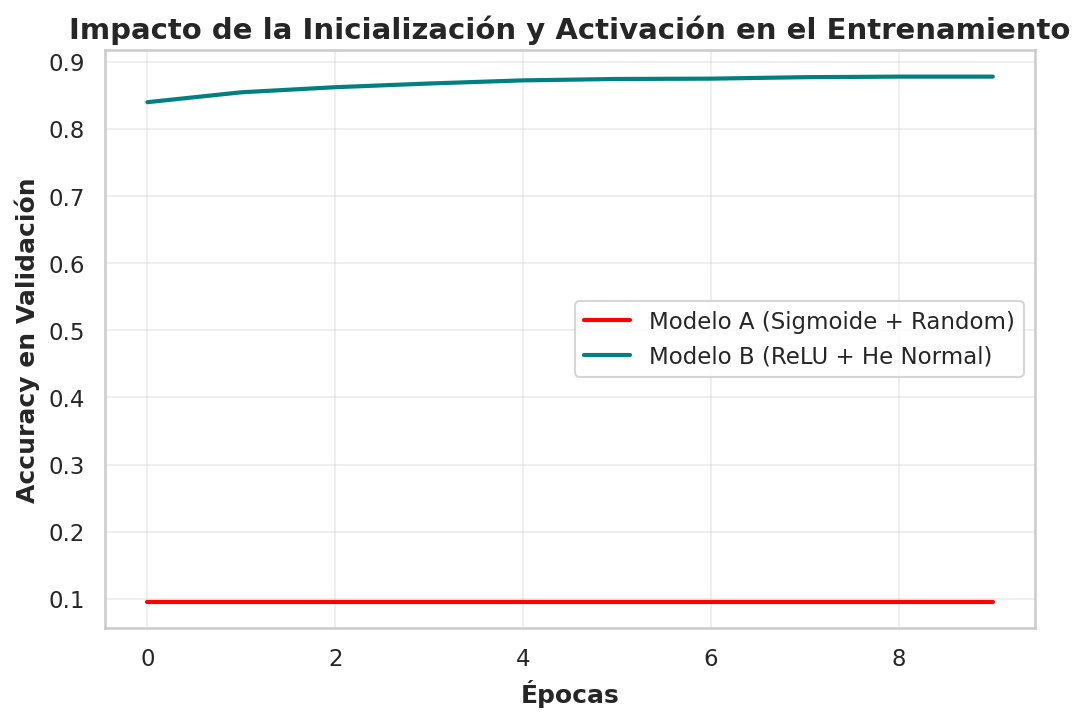

In [7]:
# 4. Visualizamos la convergencia
plt.figure(figsize=(8, 5))
plt.plot(historia_a.history['val_accuracy'], label='Modelo A (Sigmoide + Random)', color='red', linewidth=2)
plt.plot(historia_b.history['val_accuracy'], label='Modelo B (ReLU + He Normal)', color='teal', linewidth=2)

plt.title("Impacto de la Inicialización y Activación en el Entrenamiento", fontsize=14)
plt.xlabel("Épocas")
plt.ylabel("Accuracy en Validación")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Veredicto


Observar la gráfica. Al utilizar un optimizador clásico (SGD) que no enmascara los errores matemáticos, la realidad sale a la luz:

* El Modelo A (línea roja) se queda estancado en un `10%` de *Accuracy* (equivalente a adivinar al azar entre las 10 prendas de ropa). Sus gradientes se desvanecieron por completo debido a la función Sigmoide y la inicialización aleatoria. La red está matemáticamente muerta.
* El Modelo B (línea verde) alcanza casi un `90%` de *Accuracy* en apenas 10 épocas. Logra romper la barrera y aprender de forma estable

**La arquitectura es exactamente la misma (5 capas de 256 neuronas). La única diferencia es la matemática de la inicialización y la activación.**

## 5. Conexiones y Próximos Pasos


Logramos construir un MLP de 5 capas que aprende de forma estable utilizando `He Normal + ReLU`.

Sin embargo, si intentamos escalar esto a **50 capas** (como se requiere en visión por computadora avanzada), incluso la inicialización de He empezaría a fallar.
¿Por qué? Porque a medida que los pesos se actualizan durante el entrenamiento, la distribución de los datos cambia internamente en cada capa, un fenómeno conocido como ***Internal Covariate Shift***.

- ➡️ **Siguiente:** En el notebook [Normalización Batch y Layer](03_normalizacion_batch_y_layer.ipynb), descubrimos la innovación de 2015 que cambió el Deep Learning para siempre. Aprendemos a forzar matemáticamente la estabilidad de la red en tiempo real, permitiendo entrenar arquitecturas de cientos de capas a velocidades increíbles.

## Referencias


### Artículos Fundacionales

1. **Glorot, X., & Bengio, Y. (2010)**. *Understanding the difficulty of training deep feedforward neural networks*. In Proceedings of the Thirteenth International Conference on Artificial Intelligence and Statistics (AISTATS).  
   [[PDF]](https://proceedings.mlr.press/v9/glorot10a/glorot10a.pdf)

2. **He, K., Zhang, X., Ren, S., & Sun, J. (2015)**. *Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet Classification*. Proceedings of the IEEE International Conference on Computer Vision (ICCV).  
   [[arXiv]](https://arxiv.org/abs/1502.01852)

3. **Mishkin, D., & Matas, J. (2015)**. *All you need is a good init*.
   [[arXiv]](https://arxiv.org/abs/1511.06422)
   (Análisis empírico muy útil sobre inicializaciones).

### Recursos Adicionales
- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning* (Capítulo 8: Optimization for Training Deep Models). Disponible gratuitamente en deeplearningbook.org.
- Serie de videos **Neural Networks** de 3Blue1Brown – Especialmente el episodio sobre inicialización.
- Documentación oficial de Keras: [Initializers](https://keras.io/api/layers/initializers/).

### Referencias de Código
- TensorFlow/Keras Initializers API.
- Fashion MNIST dataset (Keras Datasets).

---


## Entorno de Ejecución


In [2]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.13
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
keras,3.13.2
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
